=== Unmatched files (category could not be determined) ===

=== Unique patients per category (matched only) ===
category
SPINE                 35
KNEE                  15
SHOULDER              12
HIP                    9
ANKLE                  5
ELBOW                  2
FOOT                   2
WRIST_HAND_THUMB       2
PELVIS_PUBALGIA        1
SCAPULA_RIBS_FEMUR     1

=== Per-category metric stats ===
                         PSNR                SSIM          
                         mean       std      mean       std
category                                                   
ANKLE               27.031140  3.493865  0.777176  0.060454
ELBOW               23.342641  1.478652  0.668868  0.044588
FOOT                29.473705  2.488160  0.784397  0.072224
HIP                 30.367328  5.358344  0.801932  0.141204
KNEE                25.795861  6.058769  0.729079  0.133583
PELVIS_PUBALGIA     33.302006  6.929840  0.841757  0.111146
SCAPULA_RIBS_FEMUR  29.279592  7.063041  0.806936  0.1

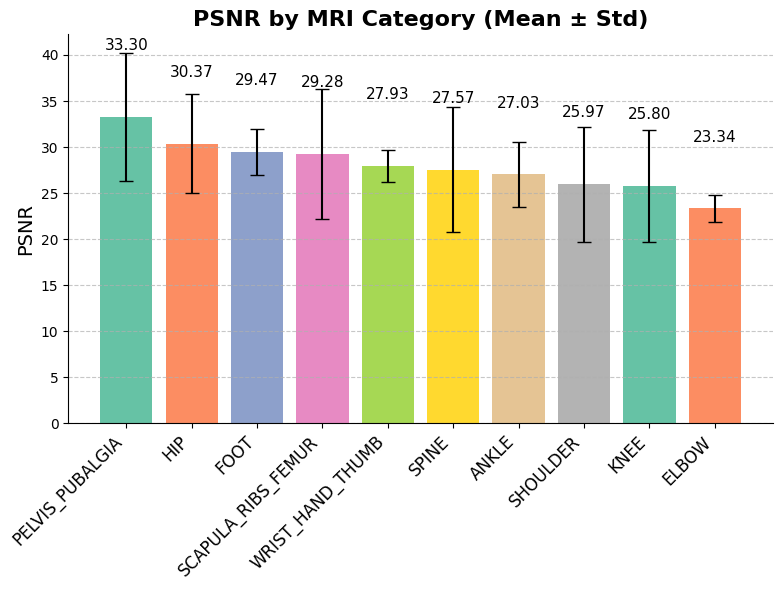

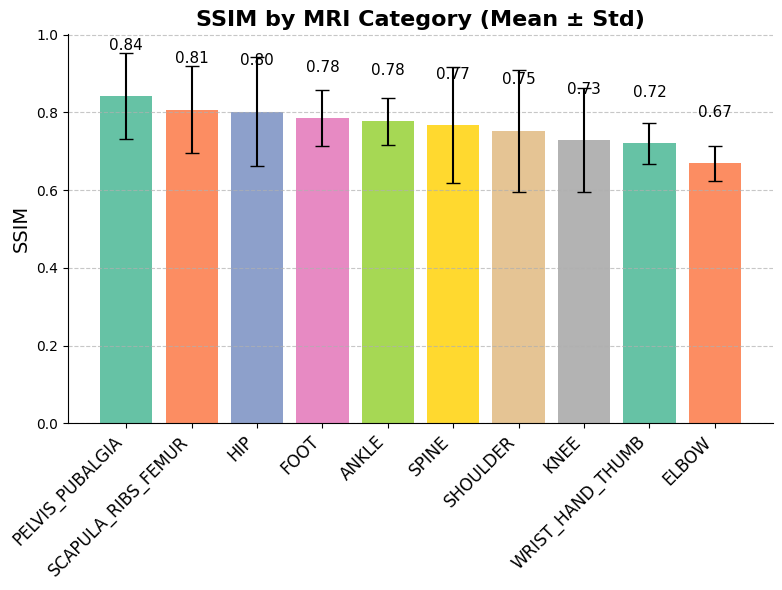

In [3]:
import os, json, h5py, xml.dom.minidom as minidom
from collections import defaultdict, Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- CONFIG: set these ----------
json_path = "./outputs/varnet_inference/metrics.json"   # path to your JSON above
data_dir  = "../../../../../data/datasets/msk_mri_h5/test_varnet"  # folder containing the .h5 files
# --------------------------------------

scan_categories = {
    "SPINE": {"includes": ["L-SPINE","LSPINE","L SPINE","C-SPINE","CSPINE","C SPINE","T-SPINE","T SPINE",
                           "AX T2 T-SP","AX T2 T-SP WARP"]},
    "KNEE": {"includes": ["LT KNEE","RT KNEE"]},
    "SHOULDER": {"includes": ["LT SHOULDER","RT SHOULDER"]},
    "HIP": {"includes": ["LT HIP","RT HIP"]},
    "ANKLE": {"includes": ["LT ANKLE","RT ANKLE"]},
    "FOOT": {"includes": ["LT FOOT","RT FOOT"]},
    "LEG_TIBFIB": {"includes": ["LT LEG","RT TIB-FIB"]},
    "ELBOW": {"includes": ["LT ELBOW","RT ELBOW"]},
    "WRIST_HAND_THUMB": {"includes": ["LT WRIST","RT WRIST","LT THUMB","RT THUMB","RT HAND","WRIST RT"]},
    "PELVIS_PUBALGIA": {"includes": ["PELVIS","ATH PUBALGIA"]},
    "SCAPULA_RIBS_FEMUR": {"includes": ["RT SCAPULA","RIBS","LT FEMUR"]},
}

def parse_header_study_and_patient(h5_path):
    """Return (tStudyDescription, patientID) from ismrmrd_header; None if missing."""
    try:
        with h5py.File(h5_path, "r") as f:
            if "ismrmrd_header" not in f:
                return None, None
            xml_raw = f["ismrmrd_header"][()]
            if isinstance(xml_raw, (bytes, bytearray, np.void)):
                xml_str = bytes(xml_raw).decode(errors="ignore")
            else:
                xml_str = str(xml_raw)
        dom = minidom.parseString(xml_str)
        # generic helper
        def _first_text(parent, tag):
            nodes = parent.getElementsByTagName(tag)
            if nodes and nodes[0].firstChild:
                return nodes[0].firstChild.data.strip()
            return None

        # userParameters may have name/value pairs
        study = None
        ups = dom.getElementsByTagName("userParameterString")
        for node in ups:
            name = _first_text(node, "name")
            if name == "tStudyDescription":
                study = _first_text(node, "value")
                break

        # fallback: try studyInformation/studyDescription (not always present)
        if study is None:
            study = _first_text(dom, "studyDescription")

        # patientID (typical location: subjectInformation/patientID)
        pid = None
        sub = dom.getElementsByTagName("subjectInformation")
        if sub:
            pid = _first_text(sub[0], "patientID")

        return study, pid
    except Exception:
        return None, None

def categorize(study_desc):
    if not study_desc:
        return None
    s = study_desc.upper()
    for cat, info in scan_categories.items():
        for token in info["includes"]:
            if token in s:
                return cat
    return None

# --------- Load JSON ----------
with open(json_path, "r") as f:
    metrics_json = json.load(f)

per_vol = metrics_json.get("per_volume", {})

# --------- Build table ----------
rows = []
unmatched = []
for fname, m in per_vol.items():
    h5_path = os.path.join(data_dir, fname)
    study, pid = parse_header_study_and_patient(h5_path)
    cat = categorize(study)
    if cat is None:
        unmatched.append((fname, study))
    rows.append({
        "file": fname,
        "category": cat,
        "study": study,
        "patientID": pid,
        "PSNR": m.get("PSNR"),
        "SSIM": m.get("SSIM"),
    })

df = pd.DataFrame(rows)

# --------- Print unmatched and patient counts ----------
print("=== Unmatched files (category could not be determined) ===")
for fname, study in unmatched:
    print(f"- {fname} | tStudyDescription={study}")

df_matched = df.dropna(subset=["category"])
patient_counts = df_matched.groupby("category")["patientID"].nunique().sort_values(ascending=False)
print("\n=== Unique patients per category (matched only) ===")
print(patient_counts.to_string())

# --------- Per-category stats ----------
stats = df_matched.groupby("category")[["PSNR","SSIM"]].agg(["mean","std"])
print("\n=== Per-category metric stats ===")
print(stats)

# --------- Plots: one figure per metric (bar of mean with std) ----------
import matplotlib.pyplot as plt

def plot_metric(metric_name):
    g = df_matched.groupby("category")[metric_name]
    means = g.mean().sort_values(ascending=False)
    stds  = g.std().reindex(means.index)
    
    plt.figure(figsize=(8, 6))
    bars = plt.bar(range(len(means)), means.values, yerr=stds.values, capsize=5, 
                   color=plt.cm.Set2.colors[:len(means)])
    
    plt.xticks(range(len(means)), means.index, rotation=45, ha='right', fontsize=12)
    plt.ylabel(metric_name, fontsize=14)
    plt.title(f"{metric_name} by MRI Category (Mean ± Std)", fontsize=16, weight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.gca().set_facecolor('white')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    # Add value labels on top of bars
    for bar, mean in zip(bars, means.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + stds.values[0], 
                 f"{mean:.2f}", ha='center', va='bottom', fontsize=11)
    
    plt.tight_layout()

for metric in ["PSNR", "SSIM"]:
    plot_metric(metric)

plt.show()


In [5]:
# Display overall average PSNR and SSIM for all matched MRI categories
avg_psnr = df_matched['PSNR'].mean()
avg_ssim = df_matched['SSIM'].mean()
print(f'Overall average PSNR: {avg_psnr:.2f}')
print(f'Overall average SSIM: {avg_ssim:.4f}')

Overall average PSNR: 27.44
Overall average SSIM: 0.7630
